# Simulation von Konfidenzintervallen

Es werden 100 Stichproben bei demselben festen Parameterwert
$p_0$ simuliert. Zunächst bleibt $p_0$ hinter dem „Vorhang“;
anschließend wird er eingezeichnet. Beide Grafiken beruhen auf
exakt denselben Stichproben.


## Eingaben


    Alle veränderbaren Eingaben stehen in der kleinen Klasse `Config`.
    Danach folgen getrennt die mathematische Berechnung und die Erzeugung
    der Grafik. Das Notebook ist selbstständig lauffähig.


In [1]:
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
import math

import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm


@dataclass(frozen=True)
class Config:
    n: int = 80
    gamma: float = 0.95
    p0: float = 0.40
    number_of_intervals: int = 100
    seed: int = 20260007
    save_figures: bool = False
    output_dir: str = "fig"


cfg = Config()


## Simulation und Berechnung

Für jede Stichprobe wird $X\sim\operatorname{Bin}(n,p_0)$ erzeugt,
$h=X/n$ berechnet und das zugehörige Wilson-Intervall bestimmt.
Der Zufallszahlengenerator wird nur einmal initialisiert. So sind
die Stichproben in beiden Darstellungen identisch.


In [2]:
z = norm.ppf((1.0 + cfg.gamma) / 2.0)


def wilson_interval(x: int) -> tuple[float, float]:
    h = x / cfg.n
    denominator = 1.0 + z**2 / cfg.n
    center = (h + z**2 / (2.0 * cfg.n)) / denominator
    half_width = (
        z
        * math.sqrt(
            h * (1.0 - h) / cfg.n
            + z**2 / (4.0 * cfg.n**2)
        )
        / denominator
    )
    return center - half_width, center + half_width


rng = np.random.default_rng(cfg.seed)
x = rng.binomial(cfg.n, cfg.p0, size=cfg.number_of_intervals)
h = x / cfg.n
intervals = np.array([wilson_interval(int(value)) for value in x])
lower = intervals[:, 0]
upper = intervals[:, 1]
covers = (lower <= cfg.p0) & (cfg.p0 <= upper)

print(
    f"{int(covers.sum())} von {cfg.number_of_intervals} "
    "Intervallen überdecken p0."
)


98 von 100 Intervallen überdecken p0.


## Gemeinsame Achsengestaltung


In [3]:
def format_axis(ax: plt.Axes) -> np.ndarray:
    y = np.arange(1, cfg.number_of_intervals + 1)
    margin = 0.025
    ax.set_xlim(
        max(0.0, float(lower.min()) - margin),
        min(1.0, float(upper.max()) + margin),
    )
    ax.set_ylim(0, cfg.number_of_intervals + 1)
    ax.set_xlabel(r"$p$", fontsize=17)
    ax.set_ylabel("Stichprobe", fontsize=14)

    tick_step = max(1, cfg.number_of_intervals // 5)
    ticks = list(range(1, cfg.number_of_intervals + 1, tick_step))
    if cfg.number_of_intervals not in ticks:
        ticks.append(cfg.number_of_intervals)
    ax.set_yticks(ticks)
    ax.tick_params(labelsize=11)
    return y


def save(fig: plt.Figure, filename: str) -> None:
    if not cfg.save_figures:
        return
    output_dir = Path(cfg.output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    fig.savefig(output_dir / f"{filename}.pdf", bbox_inches="tight")
    fig.savefig(
        output_dir / f"{filename}.png",
        dpi=240,
        bbox_inches="tight",
    )


## Vorhang geschlossen

Die Intervalle und die beobachteten relativen Häufigkeiten sind
sichtbar. Ob ein Intervall den festen Parameterwert überdeckt,
kann noch nicht entschieden werden.


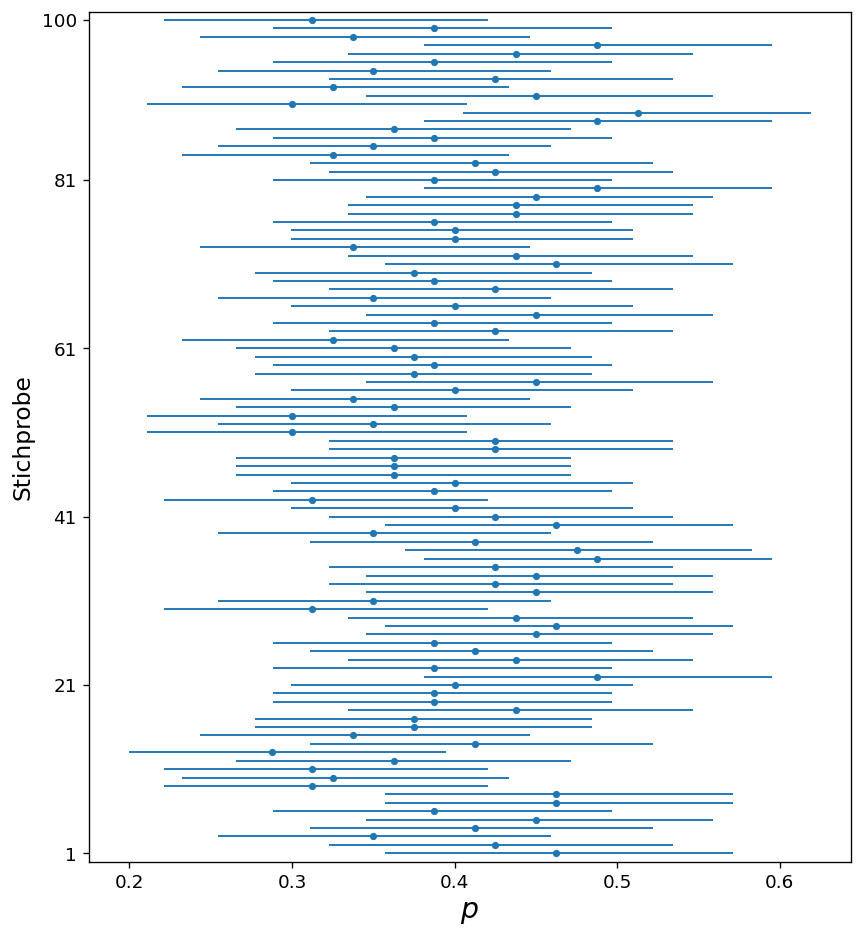

In [4]:
fig_before, ax_before = plt.subplots(figsize=(8.2, 9.2))
y = format_axis(ax_before)
ax_before.hlines(y, lower, upper, linewidth=1.15)
ax_before.scatter(h, y, s=11, zorder=4)
save(fig_before, "02a_intervalle_vorhang_geschlossen")
plt.show()


## Vorhang geöffnet

Nun wird $p_0$ eingezeichnet. Klassifiziert werden die
Realisationen $h$: grüne Punkte gehören zu überdeckenden,
rote Kreuze zu nicht überdeckenden Intervallen.


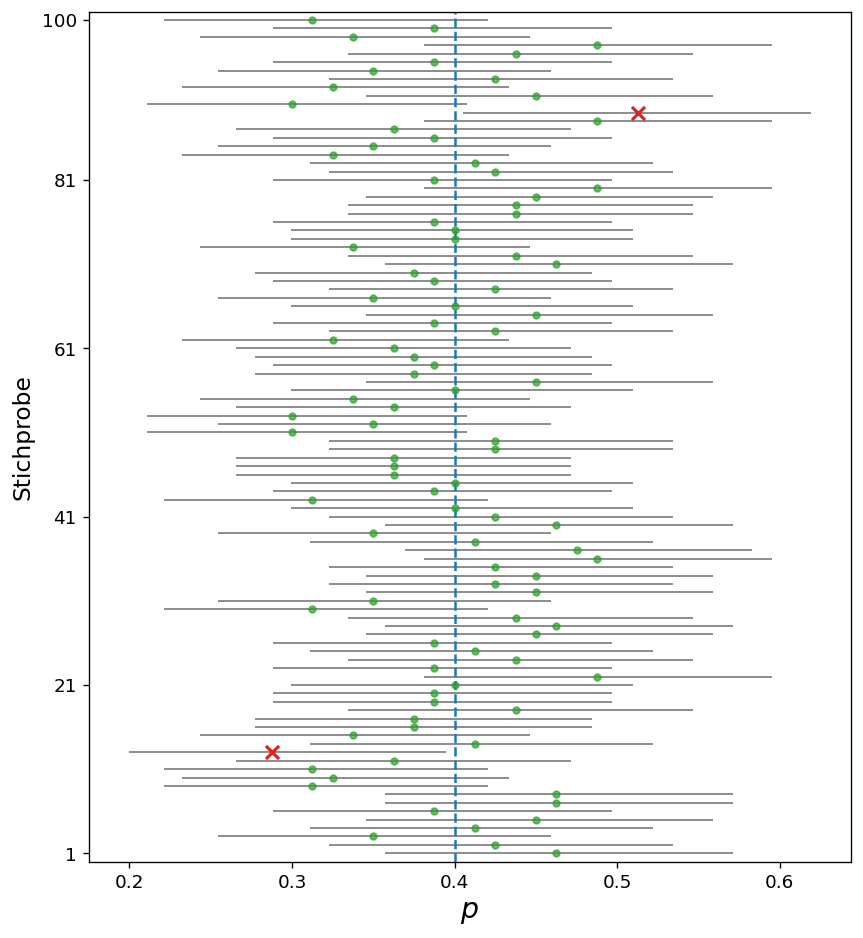

In [5]:
fig_after, ax_after = plt.subplots(figsize=(8.2, 9.2))
y = format_axis(ax_after)

ax_after.hlines(y, lower, upper, linewidth=1.05, color="0.50")
ax_after.scatter(
    h[covers],
    y[covers],
    s=16,
    alpha=0.70,
    color="tab:green",
    zorder=3,
)
ax_after.scatter(
    h[~covers],
    y[~covers],
    marker="x",
    s=62,
    linewidths=1.9,
    color="tab:red",
    zorder=4,
)
ax_after.axvline(cfg.p0, linestyle="--", linewidth=1.5, zorder=2)

save(fig_after, "02b_intervalle_vorhang_geoeffnet")
plt.show()


## Mögliche Veränderungen

Eine neue Wiederholung erhält man durch Änderung des Seeds.
Änderungen von $p_0$ oder $n$ machen sichtbar, welche Aussagen
verfahrensbezogen und welche stichprobenbezogen sind.
